In [12]:
# PHASE 8 — MODÉLISATION PRÉDICTIVE

# Objectif : Entraîner 3 modèles ML pour prédire is_loyal :
#   1. Logistic Regression (modèle de référence)
#   2. Random Forest (ensemble d'arbres)
#   3. XGBoost (gradient boosting)

In [13]:
# CELLULE 0 — Connexion Google Drive

from google.colab import drive
drive.mount('/content/drive')

import os, glob, shutil, pickle

PROJECT_PATH = "/content/drive/MyDrive/DDDM_Projet/projetDDD"
CODE_PATH    = "/content/drive/MyDrive/DDDM_Projet/projetDDD/code"

print("✓ Drive monté")
print("Contenu :", os.listdir(PROJECT_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive monté
Contenu : ['eda_ca_mensuel.png', 'eda_croissance_ca.png', 'eda_ca_categorie.png', 'eda_distribution_clients.png', 'eda_top_clients.png', 'eda_distribution_depenses.png', 'eda_clients_par_etat.png', 'eda_top_produits_volume.png', 'eda_produits_ca_vs_volume.png', 'eda_distribution_prix.png', 'eda_satisfaction.png', 'eda_satisfaction_categorie.png', 'eda_livraison_distribution.png', 'eda_retard_vs_satisfaction.png', 'eda_retard_mensuel.png', 'eda_correlation_heatmap.png', 'eda_scatter_matrix.png', 'eda_outliers_boxplot.png', 'eda_violin_plots.png', 'test1_retard_satisfaction.png', 'test2_categorie_satisfaction.png', 'test3_fidelite_depense.png', 'test5_etat_retard.png', 'test_recap_pvalues.png', 'code.zip', 'Amazon Product Reviews Dataset', 'Instacart Market Basket Analysis', 'code', 'Brazilian E-Commerce Public Dataset by Olist']


In [14]:
# CELLULE 1 — Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                      f1_score, roc_auc_score, roc_curve,
                                      confusion_matrix, classification_report,
                                      precision_recall_curve, average_precision_score)
# XGBoost
try:
    from xgboost import XGBClassifier
except ImportError:
    os.system('pip install xgboost -q')
    from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11
print("✓ Imports OK")

✓ Imports OK


In [15]:
# CELLULE 2 — Chargement du Dataset

# On charge dataset_ml.csv (Phase 7) directement

ml_path = f'{CODE_PATH}/dataset_ml.csv'
df_ml = pd.read_csv(ml_path)
print(f"✓ dataset_ml.csv chargé : {ca.shape}")
print(f"  Colonnes : {list(df_ml.columns)}")

TARGET = 'is_loyal'

FEATURES = [c for c in df_ml.columns if c != TARGET]
X = df_ml[FEATURES].copy()
Y = df_ml[TARGET].copy()

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print(f"\n Features ({len(FEATURES)}) : {FEATURES}")
print(f"\n  is_loyal=0 : {(Y==0).sum():,} ({(Y==0).mean()*100:.1f}%)")
print(f"  is_loyal=1 : {(Y==1).sum():,} ({(Y==1).mean()*100:.1f}%)")

✓ dataset_ml.csv chargé : (93350, 20)
  Colonnes : ['recency_days', 'log_recency', 'total_spent', 'log_total_spent', 'state_encoded', 'is_high_value', 'is_loyal']

 Features (6) : ['recency_days', 'log_recency', 'total_spent', 'log_total_spent', 'state_encoded', 'is_high_value']

  is_loyal=0 : 90,549 (97.0%)
  is_loyal=1 : 2,801 (3.0%)


In [16]:
# CELLULE 3 — Gestion du Déséquilibre (Under-sampling 3:1)

# Dans le dataset, les clients fidèles représentent une faible proportion de la population.
# Le dataset est très déséquilibré (97% non-fidèles, 3% fidèles)
# Pour éviter que les modèles apprennent uniquement la classe majoritaire, un sous-échantillonnage (under-sampling) est appliqué.
# Stratégie : under-sampling de la majorité + class_weight dans les modèles

print("\n=== STRATÉGIE : Under-sampling équilibré ===")

Xy = X.copy()
Xy['is_loyal'] = y.values
majority = Xy[Xy['is_loyal'] == 0]
minority = Xy[Xy['is_loyal'] == 1]

majority_down = majority.sample(n=min(len(minority)*3, len(majority)), random_state=42)
df_balanced   = pd.concat([majority_down, minority]).sample(frac=1, random_state=42)

X_bal = df_balanced[FEATURES]
y_bal = df_balanced['is_loyal']

print(f"  Dataset équilibré : {len(df_balanced):,} lignes")
print(f"  Classe 0 : {(y_bal==0).sum():,} | Classe 1 : {(y_bal==1).sum():,}")
print(f"  Ratio : 3:1")


=== STRATÉGIE : Under-sampling équilibré ===
  Dataset équilibré : 11,204 lignes
  Classe 0 : 8,403 | Classe 1 : 2,801
  Ratio : 3:1


In [17]:
# CELLULE 4 — Split Train / Test

# Découpage du dataset.
# Les données sont séparées en :
#   - 80% pour l'entraînement.
#   - 20% pour les tests.
# Le découpage est stratifié afin de conserver la même proportion de classes dans les deux ensembles.

# Split stratifié (conserve le ratio des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# Normalisation (fit sur train seulement !)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✓ Split : Train={X_train.shape[0]:,} | Test={X_test.shape[0]:,}")
print(f"  Taux fidèles Train : {y_train.mean()*100:.1f}% | Test : {y_test.mean()*100:.1f}%")

✓ Split : Train=8,963 | Test=2,241
  Taux fidèles Train : 25.0% | Test : 25.0%


In [18]:
# CELLULE 5 — Fonction d'Évaluation

# Fonction générique d'évaluation.
# Cette fonction entraîne un modèle puis calcule les principales métriques utilisées dans les problèmes de classification :
# - Accuracy, Precision, Recall, F1-Score, AUC-ROC

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    metrics = {
        'Modèle'       : name,
        'Accuracy'     : accuracy_score(y_te, y_pred),
        'Precision'    : precision_score(y_te, y_pred, zero_division=0),
        'Recall'       : recall_score(y_te, y_pred, zero_division=0),
        'F1-Score'     : f1_score(y_te, y_pred, zero_division=0),
        'AUC-ROC'      : roc_auc_score(y_te, y_proba),
        'Avg Precision': average_precision_score(y_te, y_proba),
    }
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    for k in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
        print(f"  {k:12} : {metrics[k]:.4f}")
    print(f"\n{classification_report(y_te, y_pred, zero_division=0)}")
    return metrics, y_pred, y_proba, model

In [19]:
# CELLULE 6 — MODÈLE 1 : Régression Logistique

print("\n" + "="*55 + "\n  MODÈLE 1 — RÉGRESSION LOGISTIQUE\n" + "="*55)
lr_model = LogisticRegression(
    C=1.0,                             # Régularisation L2
    class_weight='balanced',           # Compense le déséquilibre résiduel
    max_iter=1000, random_state=42)
metrics_lr, pred_lr, proba_lr, lr_trained = evaluate_model(
    "Logistic Regression", lr_model,
    X_train_sc, y_train, X_test_sc, y_test)


  MODÈLE 1 — RÉGRESSION LOGISTIQUE

  Logistic Regression
  Accuracy     : 0.6671
  Precision    : 0.4113
  Recall       : 0.7696
  F1-Score     : 0.5361
  AUC-ROC      : 0.7819

              precision    recall  f1-score   support

           0       0.89      0.63      0.74      1681
           1       0.41      0.77      0.54       560

    accuracy                           0.67      2241
   macro avg       0.65      0.70      0.64      2241
weighted avg       0.77      0.67      0.69      2241



In [20]:
# CELLULE 7 — MODÈLE 2 : Random Forest

print("\n" + "="*55 + "\n  MODÈLE 2 — RANDOM FOREST\n" + "="*55)
rf_model = RandomForestClassifier(
    n_estimators=200,            # 200 arbres
    max_depth=10,                # Limite la profondeur (évite overfitting)
    min_samples_split=20,        # Minimum d'échantillons pour splitter
    class_weight='balanced',     # Compense le déséquilibre
    random_state=42,
    n_jobs=-1                   # Utilise tous les cœurs CPU
)
# RF n'a pas besoin de normalisation
metrics_rf, pred_rf, proba_rf, rf_trained = evaluate_model(
    "Random Forest", rf_model,
    X_train, y_train, X_test, y_test
)


  MODÈLE 2 — RANDOM FOREST

  Random Forest
  Accuracy     : 0.7010
  Precision    : 0.4412
  Recall       : 0.7375
  F1-Score     : 0.5521
  AUC-ROC      : 0.7867

              precision    recall  f1-score   support

           0       0.89      0.69      0.78      1681
           1       0.44      0.74      0.55       560

    accuracy                           0.70      2241
   macro avg       0.66      0.71      0.66      2241
weighted avg       0.78      0.70      0.72      2241



In [21]:
# CELLULE 8 — MODÈLE 3 : XGBoost

print("\n" + "="*55 + "\n  MODÈLE 3 — XGBOOST\n" + "="*55)
# Calculer scale_pos_weight pour gérer le déséquilibre
scale_w = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(n_estimators=200, max_depth=6,
                            learning_rate=0.1, subsample=0.8,
                            colsample_bytree=0.8,
                            scale_pos_weight=scale_w,   # Poids pour la classe minoritaire
                            use_label_encoder=False,
                            eval_metric='logloss',
                            random_state=42, n_jobs=-1, verbosity=0)
metrics_xgb, pred_xgb, proba_xgb, xgb_trained = evaluate_model(
    "XGBoost", xgb_model,
    X_train, y_train, X_test, y_test
)


  MODÈLE 3 — XGBOOST

  XGBoost
  Accuracy     : 0.6827
  Precision    : 0.4199
  Recall       : 0.7071
  F1-Score     : 0.5269
  AUC-ROC      : 0.7681

              precision    recall  f1-score   support

           0       0.87      0.67      0.76      1681
           1       0.42      0.71      0.53       560

    accuracy                           0.68      2241
   macro avg       0.65      0.69      0.64      2241
weighted avg       0.76      0.68      0.70      2241



In [22]:
# CELLULE 9 — Tableau Comparatif

# Comparaison des modèles.
# Les trois modèles sont évalués sur le même jeu de test afin d'identifier celui qui offre les meilleures performances.
# Le critère principal retenu est le F1-Score, particulièrement adapté aux jeux de données déséquilibrés.

results_df = pd.DataFrame([metrics_lr, metrics_rf, metrics_xgb]).set_index('Modèle')

print("\n" + "="*70)
print("  TABLEAU COMPARATIF — VERSION CORRIGÉE (sans fuite de données)")
print("="*70)
print(results_df.round(4).to_string())

best_name = results_df['F1-Score'].idxmax()
print(f"\nMeilleur modèle (F1) : {best_name}")
print(f"   F1-Score = {results_df.loc[best_name,'F1-Score']:.4f}")
print(f"   AUC-ROC  = {results_df.loc[best_name,'AUC-ROC']:.4f}")
print("\n✓ Scores réalistes (F1 ≈ 0.50-0.65, AUC ≈ 0.70-0.80)")


  TABLEAU COMPARATIF — VERSION CORRIGÉE (sans fuite de données)
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  Avg Precision
Modèle                                                                            
Logistic Regression    0.6671     0.4113  0.7696    0.5361   0.7819         0.4997
Random Forest          0.7010     0.4412  0.7375    0.5521   0.7867         0.5124
XGBoost                0.6827     0.4199  0.7071    0.5269   0.7681         0.4885

Meilleur modèle (F1) : Random Forest
   F1-Score = 0.5521
   AUC-ROC  = 0.7867

✓ Scores réalistes (F1 ≈ 0.50-0.65, AUC ≈ 0.70-0.80)


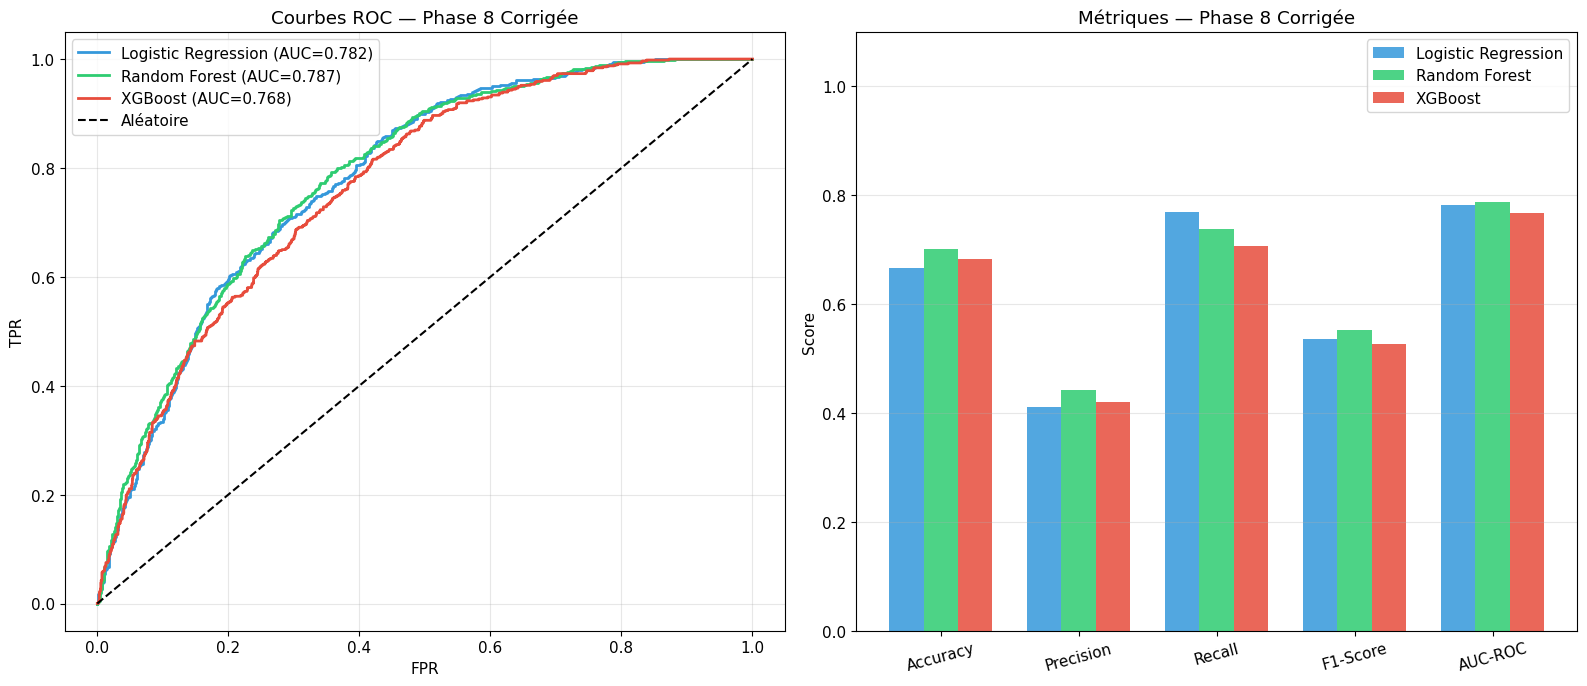

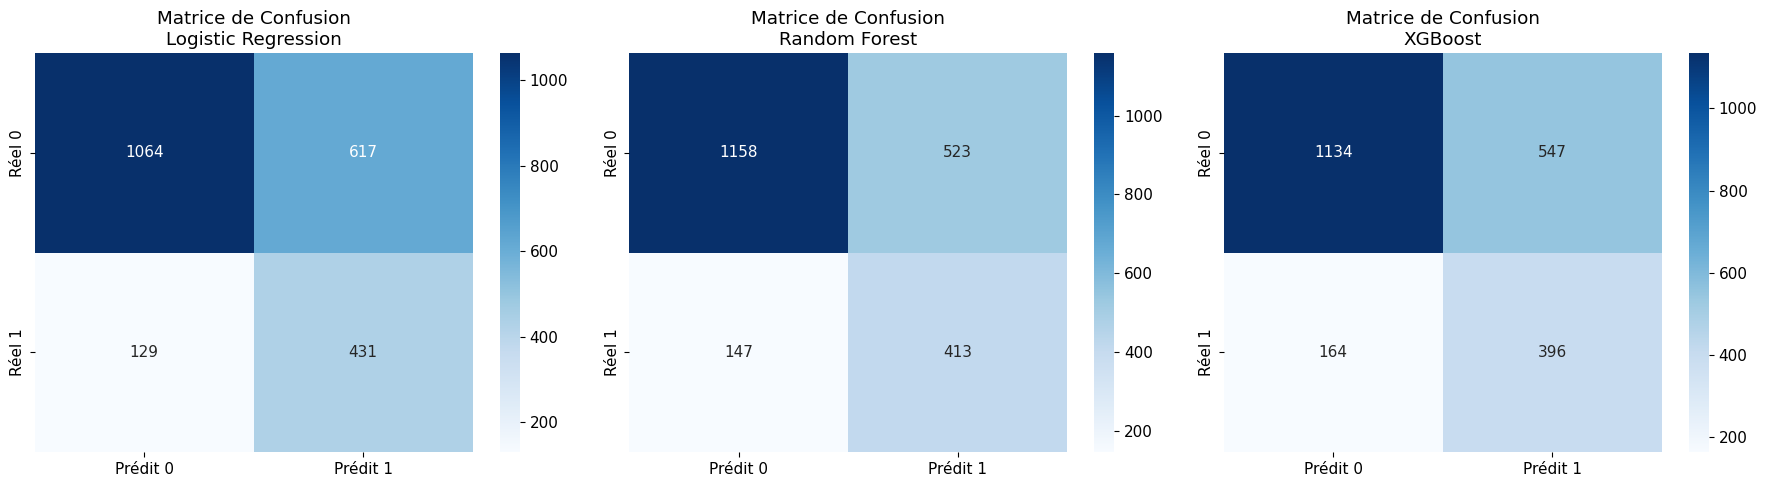

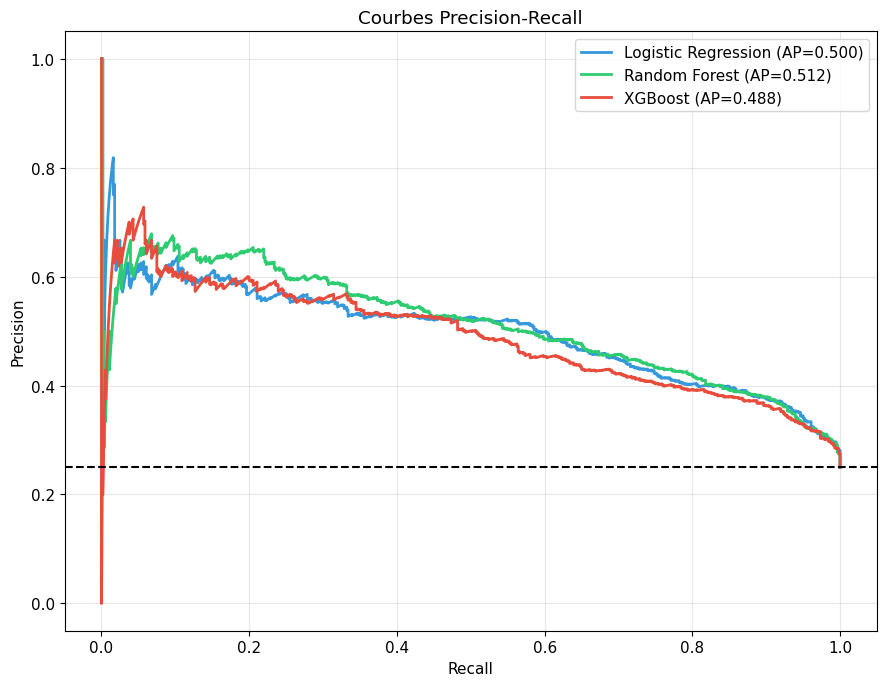

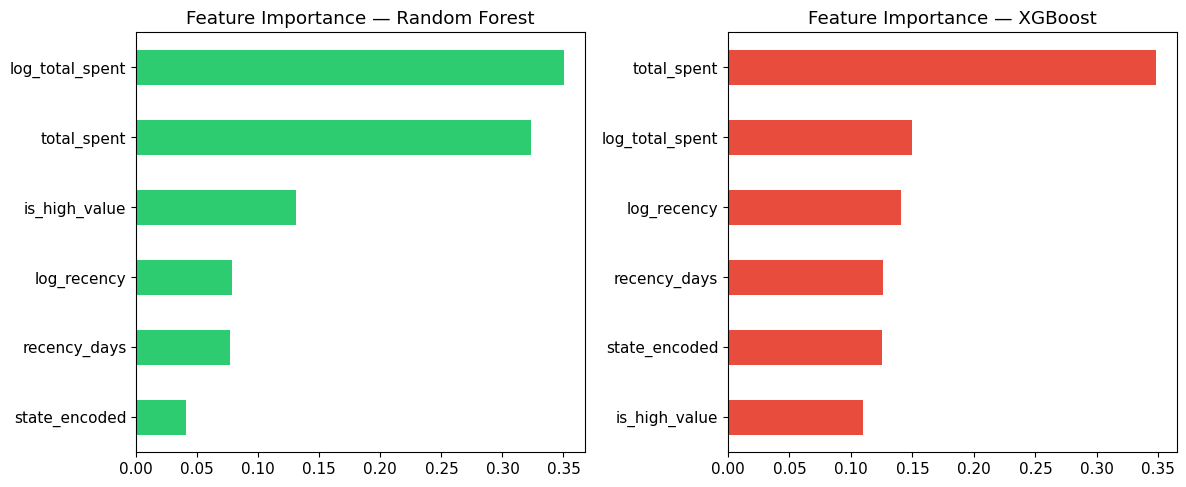

In [23]:
# CELLULE 10 — Visualisations

model_data = [
    ("Logistic Regression", proba_lr,  '#3498db'),
    ("Random Forest",        proba_rf,  '#2ecc71'),
    ("XGBoost",              proba_xgb, '#e74c3c'),
]

# Courbes ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for name, proba, color in model_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={auc_val:.3f})')
axes[0].plot([0,1],[0,1],'k--', label='Aléatoire')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Courbes ROC — Phase 8 Corrigée')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

metrics_cols = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
x = np.arange(len(metrics_cols)); w = 0.25
for i, (name, color) in enumerate([
    ("Logistic Regression",'#3498db'),
    ("Random Forest",'#2ecc71'),
    ("XGBoost",'#e74c3c')
]):
    axes[1].bar(x+i*w, results_df.loc[name, metrics_cols].values,
                w, label=name, color=color, alpha=0.85)
axes[1].set_xticks(x+w); axes[1].set_xticklabels(metrics_cols, rotation=15)
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('Score')
axes[1].set_title('Métriques — Phase 8 Corrigée')
axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('phase8_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, name in zip(axes, [pred_lr, pred_rf, pred_xgb],
                            ["Logistic Regression","Random Forest","XGBoost"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prédit 0','Prédit 1'],
                yticklabels=['Réel 0','Réel 1'])
    ax.set_title(f'Matrice de Confusion\n{name}')
plt.tight_layout()
plt.savefig('phase8_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Courbes Precision-Recall
fig, ax = plt.subplots(figsize=(9, 7))
for name, proba, color in model_data:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')
ax.axhline(y=y_test.mean(), color='k', linestyle='--')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Courbes Precision-Recall')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase8_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importances
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
rf_imp  = pd.Series(rf_trained.feature_importances_, index=FEATURES).sort_values(ascending=True)
xgb_imp = pd.Series(xgb_trained.feature_importances_, index=FEATURES).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[0], color='#2ecc71')
axes[0].set_title('Feature Importance — Random Forest')
xgb_imp.plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('phase8_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# CELLULE 11 — Sauvegarde des Modèles

# Les modèles sont exportés au format Pickle afin de pouvoirêtre réutilisés dans les phases suivantes :
# Validation finale, Interprétabilité (SHAP), Dashboard décisionnel

models_dict = {
    'logistic_regression': (lr_trained, scaler),
    'random_forest':       (rf_trained, None),
    'xgboost':             (xgb_trained, None),
}
for mname, (model, sc) in models_dict.items():
    fname = f'model_{mname}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump({'model': model, 'scaler': sc, 'features': FEATURES}, f)
    shutil.copy(fname, f'{CODE_PATH}/{fname}')
    print(f"✓ Sauvegardé : {fname}")

with open('train_test_data.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'X_train_sc': X_train_sc, 'X_test_sc': X_test_sc,
        'FEATURES': FEATURES, 'scaler': scaler
    }, f)
shutil.copy('train_test_data.pkl', f'{CODE_PATH}/train_test_data.pkl')
print("✓ train_test_data.pkl sauvegardé")

✓ Sauvegardé : model_logistic_regression.pkl
✓ Sauvegardé : model_random_forest.pkl
✓ Sauvegardé : model_xgboost.pkl
✓ train_test_data.pkl sauvegardé


In [25]:
# CELLULE 12 — Synthèse Phase 8

print("\n" + "="*70)
print("  SYNTHÈSE PHASE 8 : MODÉLISATION PRÉDICTIVE (CORRIGÉE)")
print("="*70)
print(f"""
PROBLÈME RÉSOLU : Fuite de données structurelle détectée et corrigée.
  Les variables avg_* (moyennes sur N commandes) révèlent nb_orders.
  → Elles ont été retirées du dataset ML.

FEATURES RETENUES : {FEATURES}
VARIABLE CIBLE    : is_loyal
SPLIT             : 80%/20% stratifié
DÉSÉQUILIBRE      : Under-sampling 3:1 + class_weight='balanced'
""")
print(results_df.round(4).to_string())
print(f"\nMeilleur modèle : {best_name}")

graphs = ['phase8_roc_comparison.png', 'phase8_confusion_matrices.png',
          'phase8_precision_recall.png', 'phase8_feature_importances.png']
print(f"\nGraphiques ({len(graphs)}) :")
for g in graphs: print(f"  ✓ {g}")
print("\n✓ Phase 8 terminée — prêt pour Phase 9 (Validation & Comparaison)")


  SYNTHÈSE PHASE 8 : MODÉLISATION PRÉDICTIVE (CORRIGÉE)

PROBLÈME RÉSOLU : Fuite de données structurelle détectée et corrigée.
  Les variables avg_* (moyennes sur N commandes) révèlent nb_orders.
  → Elles ont été retirées du dataset ML.
 
FEATURES RETENUES : ['recency_days', 'log_recency', 'total_spent', 'log_total_spent', 'state_encoded', 'is_high_value']
VARIABLE CIBLE    : is_loyal
SPLIT             : 80%/20% stratifié
DÉSÉQUILIBRE      : Under-sampling 3:1 + class_weight='balanced'

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  Avg Precision
Modèle                                                                            
Logistic Regression    0.6671     0.4113  0.7696    0.5361   0.7819         0.4997
Random Forest          0.7010     0.4412  0.7375    0.5521   0.7867         0.5124
XGBoost                0.6827     0.4199  0.7071    0.5269   0.7681         0.4885

Meilleur modèle : Random Forest

Graphiques (4) :
  ✓ phase8_roc_comparison.png
  ✓ phase8